In [ ]:
!pip -q install ultralytics roboflow supervision

from ultralytics import YOLO
from google.colab import drive
import os, glob

!nvidia-smi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Sun Feb 22 15:27:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.

In [ ]:
drive.mount('/content/drive')

HOME = os.getcwd()
print("HOME:", HOME)

Mounted at /content/drive
HOME: /content


In [ ]:
ZIP_PATH = "/content/drive/MyDrive/Capstone_4/vehicle-detection.v1i.yolov12.zip"
!cp "{ZIP_PATH}" /content/

!ls -lh /content/vehicle-detection.v1i.yolov12.zip

-rw------- 1 root root 516M Feb 22 15:36 /content/vehicle-detection.v1i.yolov12.zip


In [ ]:
DATA_DIR = "/content/vehicle_dataset"
!rm -rf "{DATA_DIR}"
!mkdir -p "{DATA_DIR}"
!unzip -q "/content/vehicle-detection.v1i.yolov12.zip" -d "{DATA_DIR}"

# cari data.yaml
yaml_candidates = glob.glob(f"{DATA_DIR}/**/data.yaml", recursive=True)
print("YAML candidates:", yaml_candidates)
assert len(yaml_candidates) > 0, "data.yaml tidak ditemukan setelah unzip!"

data_yaml = yaml_candidates[0]
dataset_location = os.path.dirname(data_yaml)

print("dataset_location:", dataset_location)
print("data_yaml:", data_yaml)

# cek isi yaml
!cat "{data_yaml}"

# cek struktur folder
!ls "{dataset_location}"
!ls "{dataset_location}/train/images" | head
!ls "{dataset_location}/valid/images" | head
!ls "{dataset_location}/test/images"  | head

YAML candidates: ['/content/vehicle_dataset/data.yaml']
dataset_location: /content/vehicle_dataset
data_yaml: /content/vehicle_dataset/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
00b1884d72d57a22_jpg.rf.0067aab283d9b7884844e931c8166c47.jpg
00b1884d72d57a22_jpg.rf.8b95a2a5196c3560af47d300447b0400.jpg
00b1884d72d57a22_jpg.rf.c205c44f5e4dc4700d56d1837c4eb1d3.jpg
00c0e508d6ad8af3_jpg.rf.455de8b5ef37aff76bff93cb1f76eaf5.jpg
00c0e508d6ad8af3_jpg.rf.8545443adc989c858ddf0541dcd0b58e.jpg
00c0e508d6ad8af3_jpg.rf.a6e624de84b4ee0e3f00c0e9f62af25b.jpg
00c9f3f8e860c48f_jpg.rf.2c87ec721263177f091d79808330d13e.jpg
00c9f3f8e860c48f_jpg.rf.82fa5af6e47

In [ ]:
!wget -q -O /content/yolov12n.pt https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
!ls -lh /content/yolov12n.pt


-rw-r--r-- 1 root root 5.4M Feb 19  2025 /content/yolov12n.pt


In [ ]:
model = YOLO("/content/yolov12n.pt")

results = model.train(
    data=data_yaml,
    epochs=40,
    imgsz=640,
    batch=16,
    name="vehicle_ft_yolov12n",
    exist_ok=True,

    # training behavior
    patience=10,
    save_period=10,
    val=True,
    verbose=True,

    # optional tuning
    lr0=0.005,
    lrf=0.01,
    weight_decay=0.0005,

    # augment non-geometrik
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # stabil untuk small dataset
    close_mosaic=10
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_ft_yolov12n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [ ]:
model.val(data=data_yaml)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1883.6±855.9 MB/s, size: 84.7 KB)
val: Scanning /content/vehicle_dataset/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 109.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.8it/s 3.8s
                   all        287        427      0.868      0.827      0.915        0.7
                   bus         67        113      0.924      0.796      0.933      0.672
                   car        21

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x788c5df62a50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
test_imgs = glob.glob(f"{dataset_location}/test/images/*")
assert len(test_imgs) > 0, "Folder test/images kosong!"
sample_img = test_imgs[0]
print("Sample img:", sample_img)

model.predict(
    source=sample_img,
    conf=0.25,
    iou=0.7,
    save=True
)

Sample img: /content/vehicle_dataset/test/images/IMG_20250325_113243_jpg.rf.092f1573b166168034207395e0cd01a5.jpg

image 1/1 /content/vehicle_dataset/test/images/IMG_20250325_113243_jpg.rf.092f1573b166168034207395e0cd01a5.jpg: 640x480 (no detections), 71.1ms
Speed: 2.8ms preprocess, 71.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bus', 1: 'car', 2: 'van'}
 obb: None
 orig_img: array([[[  5,  11,   6],
         [  5,  11,   6],
         [  6,  12,   7],
         ...,
         [101,  76,  42],
         [102,  77,  43],
         [102,  77,  43]],
 
        [[  5,  11,   6],
         [  5,  11,   6],
         [  6,  12,   7],
         ...,
         [101,  76,  42],
         [102,  77,  43],
         [102,  77,  43]],
 
        [[  5,  11,   6],
         [  5,  11,   6],
         [  6,  12,   7],
         ...,
         [101,  76,  42],
         [102,  77,  43],
         [102,  77,  43]],
 
        ...,
 
        [[ 47, 131, 173],
         [ 47, 131, 173],
         [ 47, 131, 173],
         ...,
         [185, 196, 204],
         [186, 197, 205],
         [187, 198, 206]],
 
        [[ 47, 131, 173],
         [ 47, 131, 173],
         [ 47, 131, 173],
         ...,
 

RUN_DIR: /content/runs/detect/my_model
args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch5770.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch5771.jpg  weights
labels.jpg			 train_batch5772.jpg


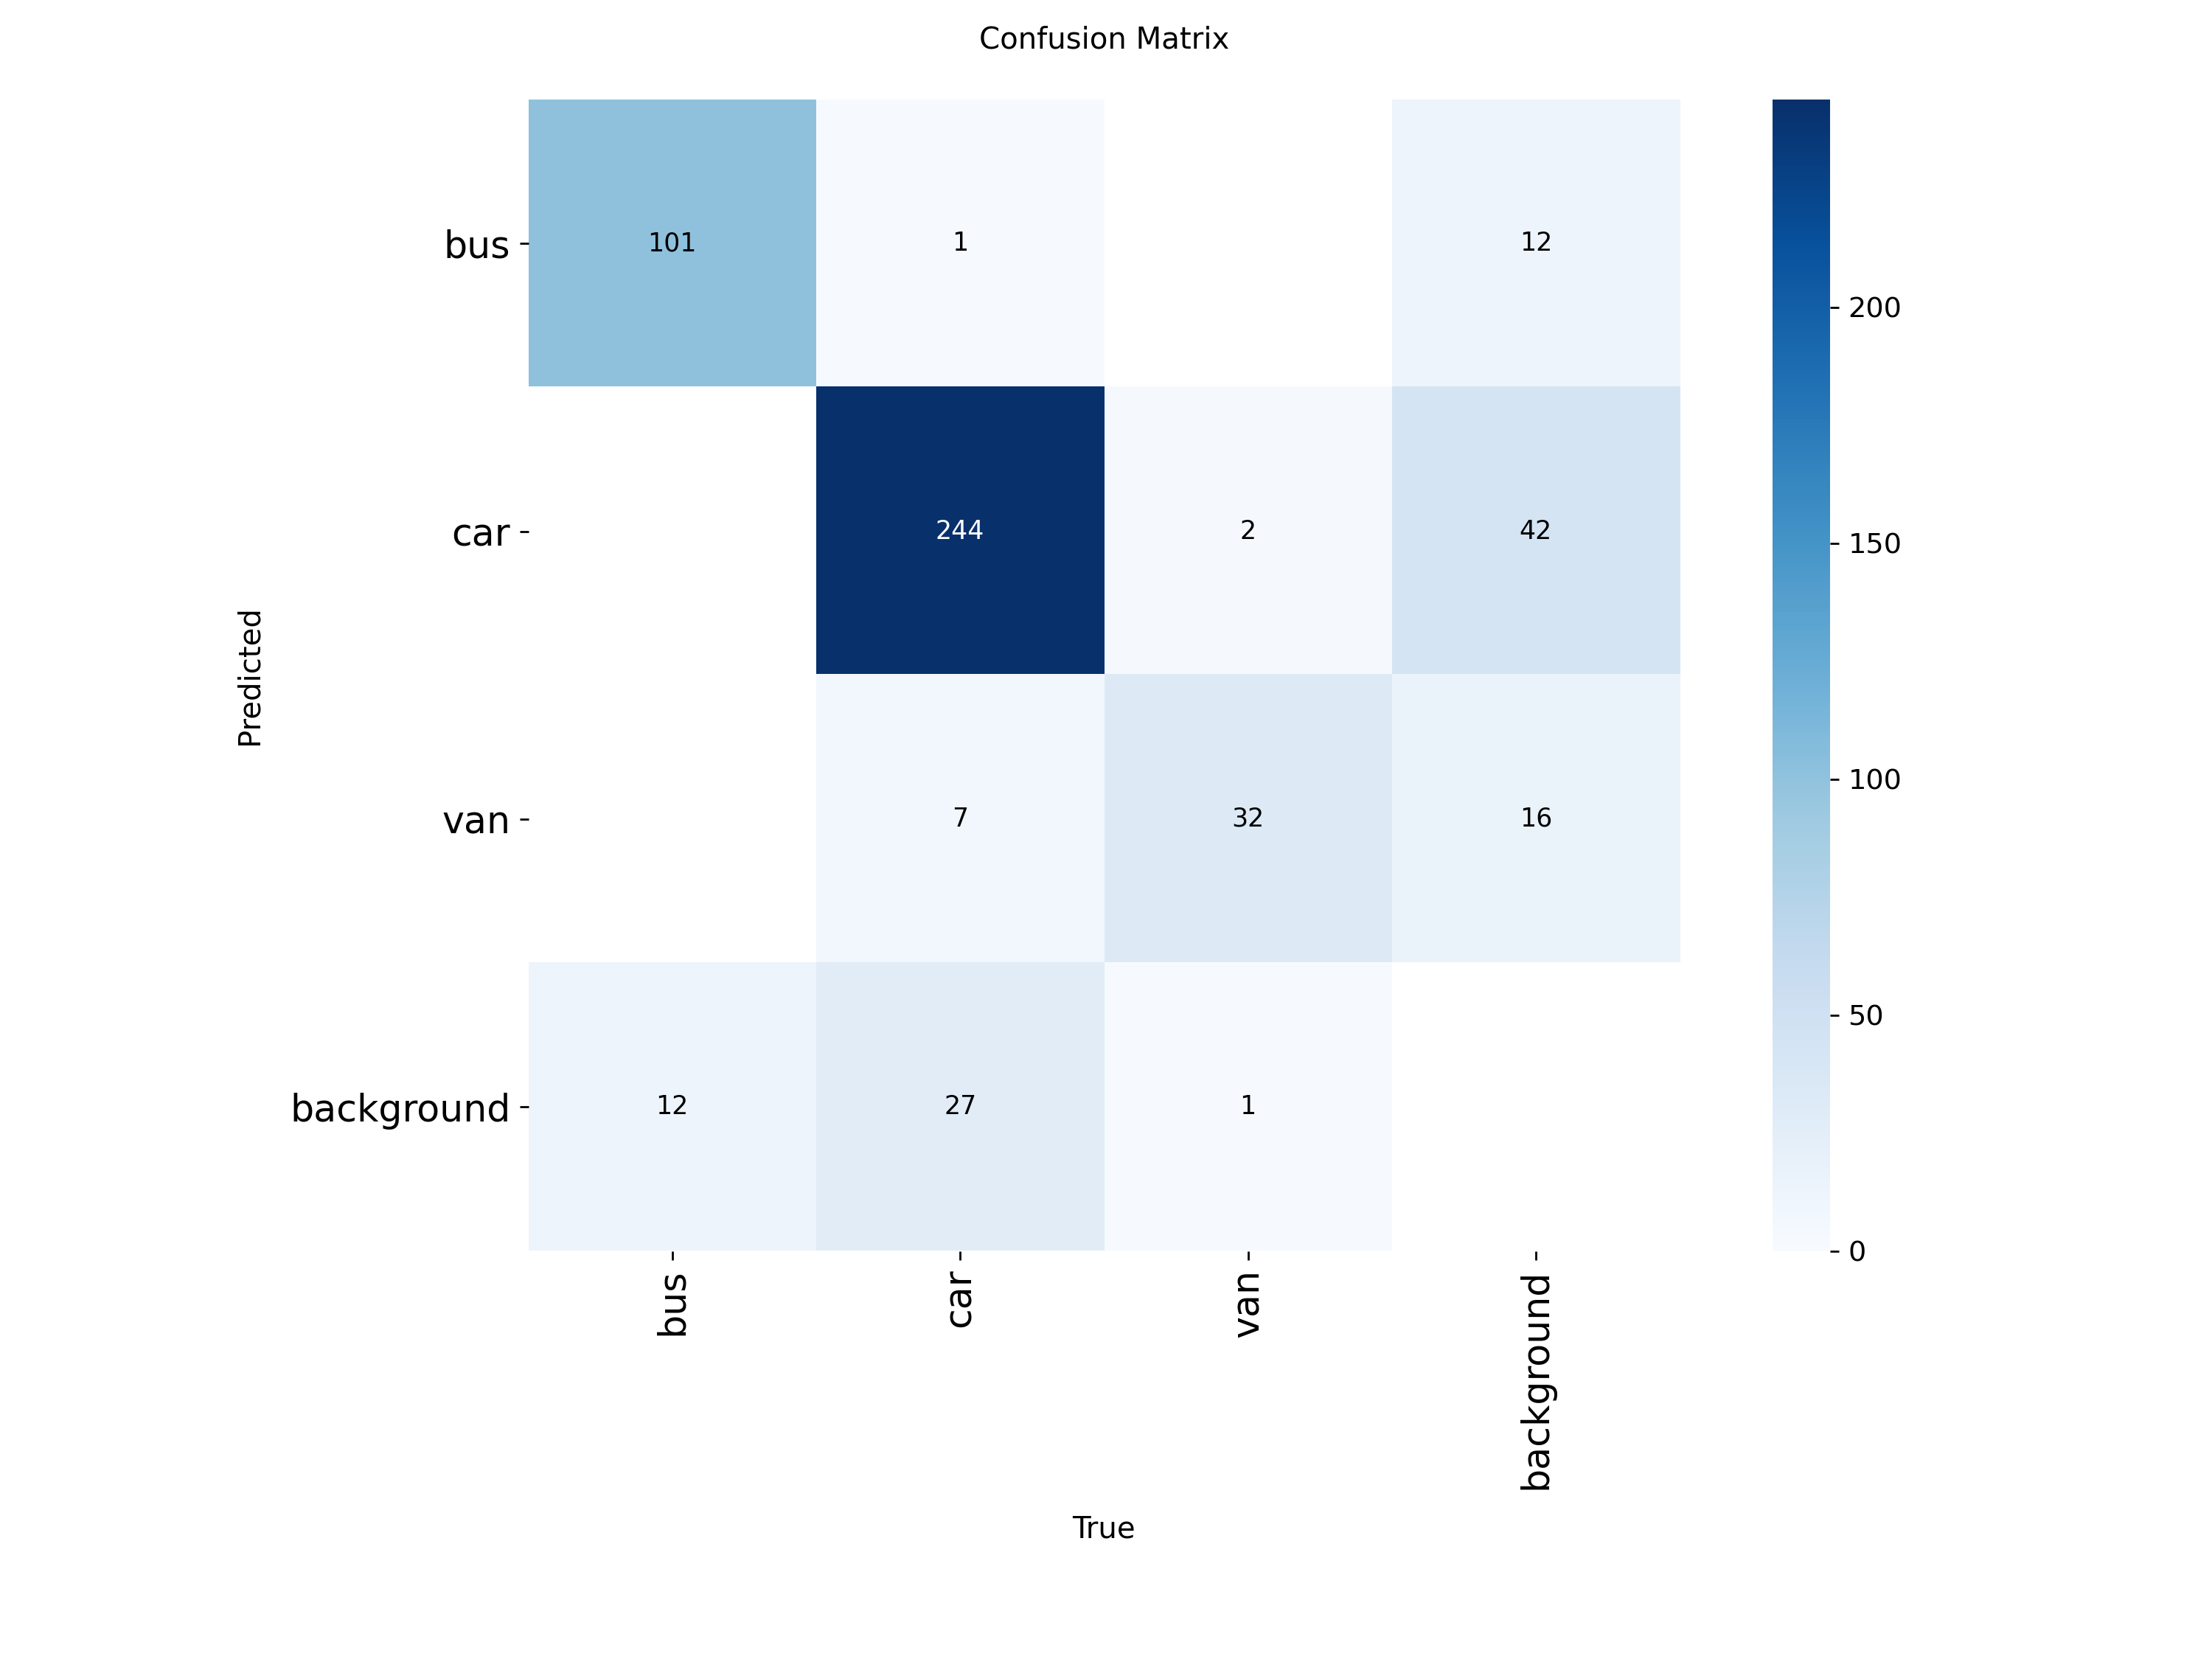

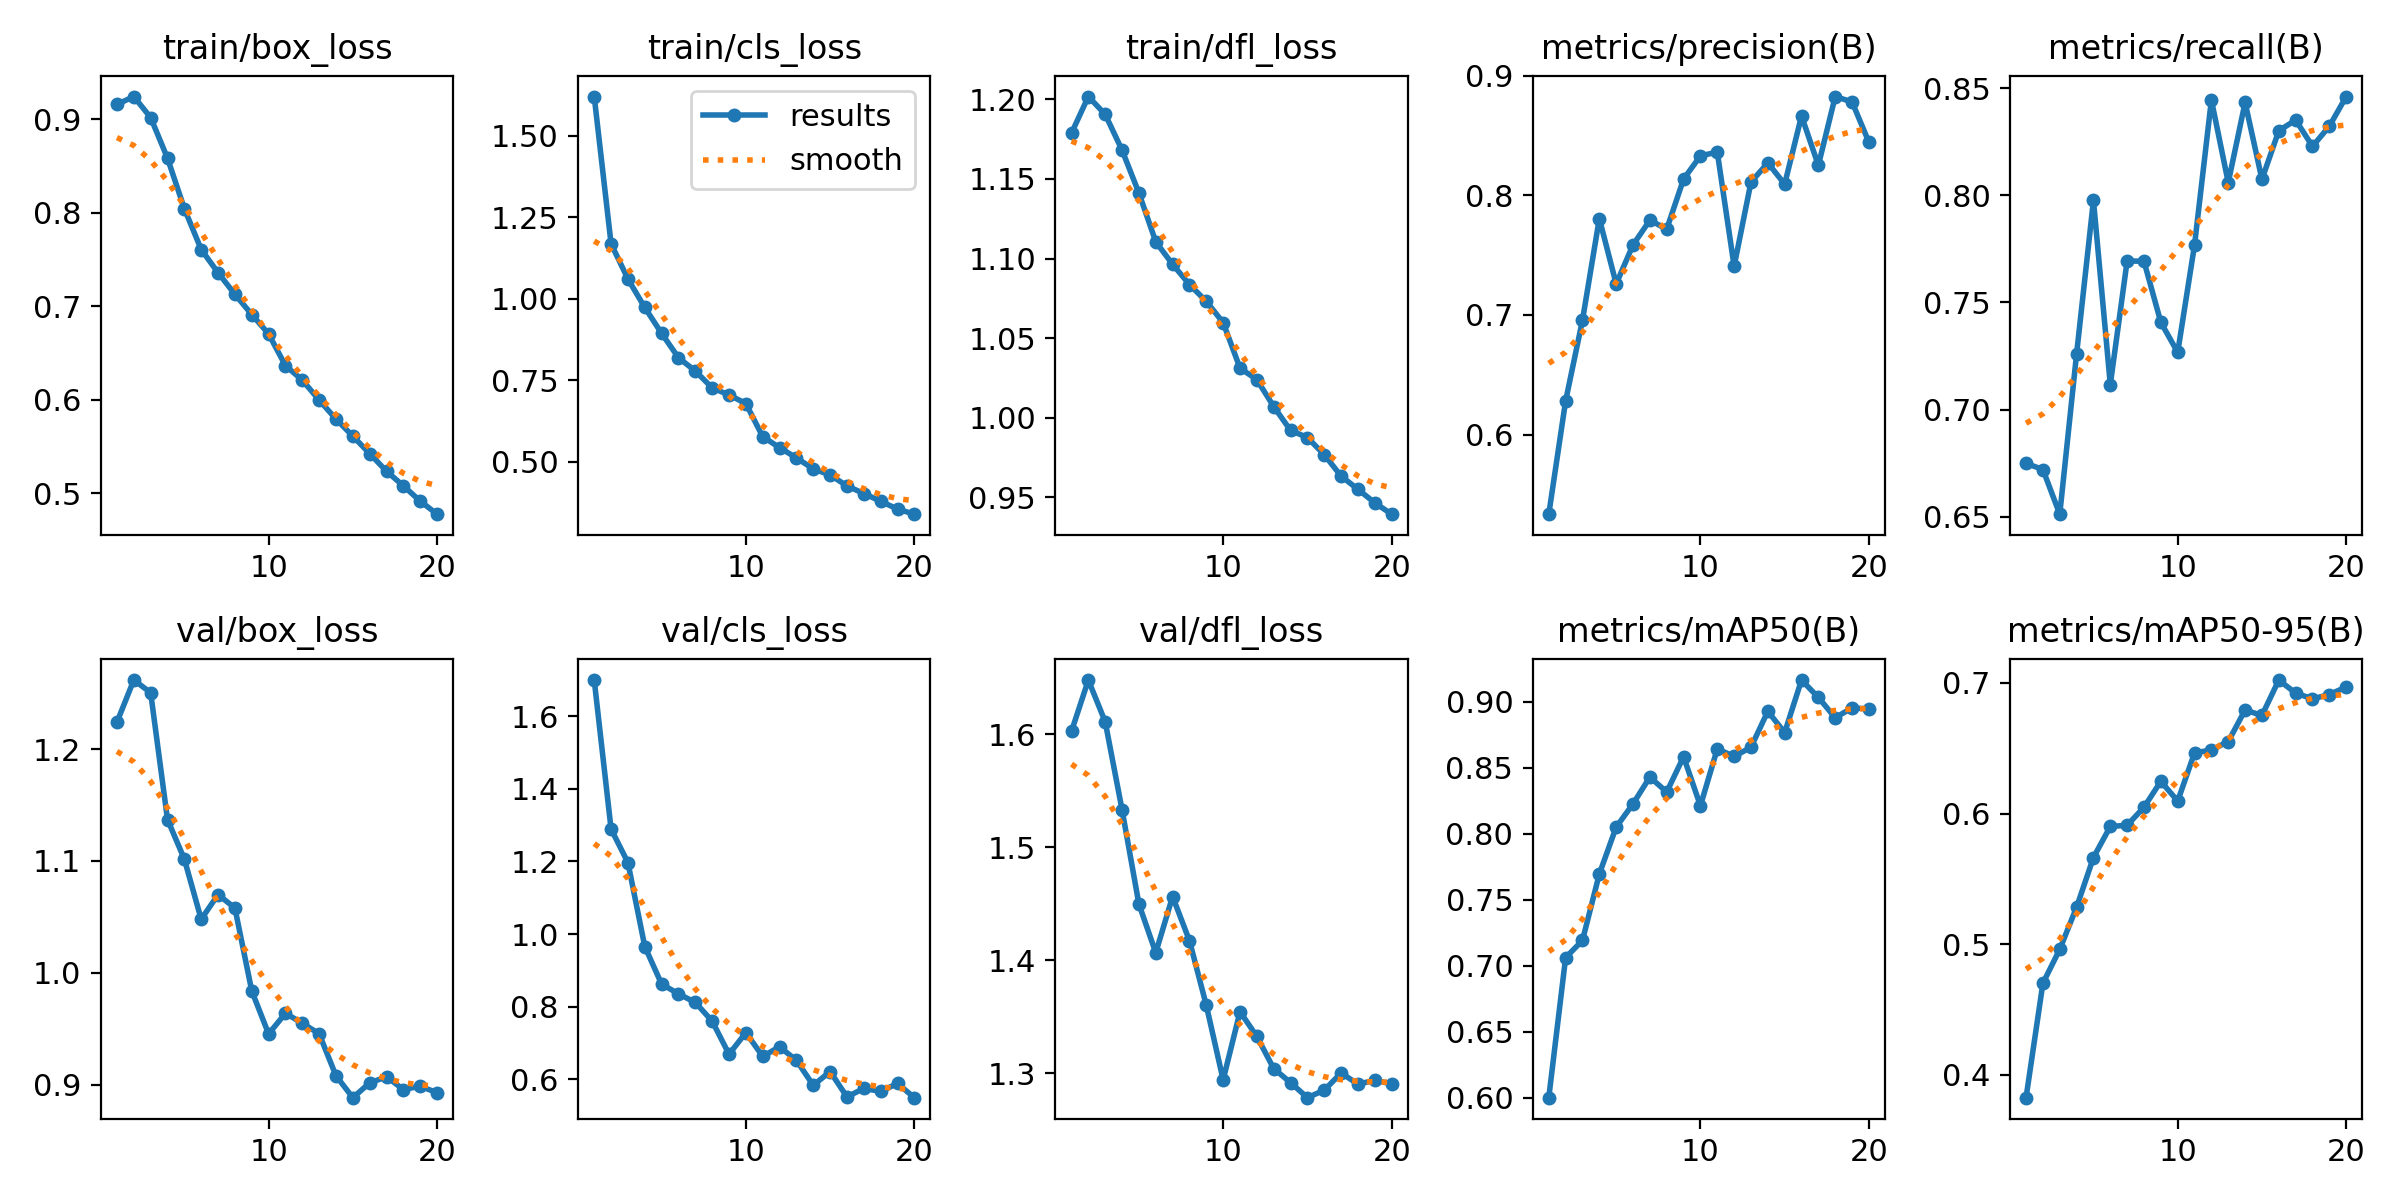

In [ ]:
RUN_DIR = f"{HOME}/runs/detect/my_model"
print("RUN_DIR:", RUN_DIR)
!ls "{RUN_DIR}"

from IPython.display import Image, display

if os.path.exists(f"{RUN_DIR}/confusion_matrix.png"):
    display(Image(filename=f"{RUN_DIR}/confusion_matrix.png", width=1000))

if os.path.exists(f"{RUN_DIR}/results.png"):
    display(Image(filename=f"{RUN_DIR}/results.png", width=1000))

In [ ]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=data_yaml
)

best_model = YOLO(f"{RUN_DIR}/weights/best.pt")

predictions, targets = [], []
for _, image, target in ds:
    res = best_model(image, verbose=False)[0]
    det = sv.Detections.from_ultralytics(res)
    predictions.append(det)
    targets.append(target)

map_metrics = MeanAveragePrecision().update(predictions, targets).compute()
print("mAP metrics:", map_metrics)

mAP metrics: Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.633
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.803
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.727
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.220
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.322
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.695


In [ ]:
DEST = "/content/drive/MyDrive/Capstone_4/best.pt"
!cp "{RUN_DIR}/weights/best.pt" "{DEST}"
print("Saved to:", DEST)

Saved to: /content/drive/MyDrive/Capstone_4/best.pt
